In [1]:
import sys
import os
import json

from directlfq.lfq_manager import run_lfq
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl

sys.path.append('../..') 
from quantification.lfq import quantify_fragments

/home/caro/MuMDIA/.venv/lib/python3.11/site-packages/psims/mzmlb/writer.py:33: UserWarning: hdf5plugin is missing! Only the slower GZIP compression scheme will be available! Please install hdf5plugin to be able to use Blosc.
  warnings.warn(


In [2]:
def run_quant(condition: str):
    df_fragment = pl.read_csv("../testfiles/condition{}_fullmzml/df_fragment_after_ms2pip.tsv".format(condition), separator="\t")
    mokapot_results = "../testfiles/condition{}_fullmzml/mokapot.peptides.txt".format(condition)
    config = json.load(open("../../configs/config_condition{}_fullmzml.json".format(condition)))

    quantify_fragments(df_fragment, mokapot_results, config, output_dir="quant_out/")

def assign_species(protein_str):
    if "HUMAN" in protein_str:
        return "HUMAN"
    elif "ECOLI" in protein_str:
        return "ECOLI"
    elif "YEAST" in protein_str:
        return "YEAST"
    else:
        print("Warning: Protein not assigned to any species: ", protein_str)
        return "OTHER"

def plot_logfc_histograms(directLFQ_protein_intensities):
    # plot log2FC distribution by species
    # create a new column "Species" based on the "protein" column
    directLFQ_protein_intensities = directLFQ_protein_intensities.with_columns(
        pl.col("protein").map_elements(assign_species).alias("Species")
    )
    species_colors = {
        "HUMAN": "green",
        "ECOLI": "blue",
        "YEAST": "red",
        "OTHER": "gray"
    }   

    quant_pd = directLFQ_protein_intensities.to_pandas()
    plt.figure(figsize=(10, 6))
    for species, color in species_colors.items():
        subset = quant_pd[quant_pd["Species"] == species]
        plt.hist(subset["log2FC_A_vs_B"], bins=150, alpha=0.5, label=species, color=color)   
    plt.xlabel("log2 Fold Change (A vs B)")
    plt.ylabel("Frequency")
    plt.title("Distribution of log2 Fold Changes by Species")
    plt.legend()
    plt.axvline(x=1, color='red', linestyle='--')
    plt.axvline(x=-2, color='blue', linestyle='--')
    plt.axvline(x=0, color='green', linestyle='--')
    plt.tight_layout()
    plt.savefig("quant_out/log2FC_histogram_by_species.png")
    plt.show()

    return

In [3]:
def quantify_proteins(df_fragment_quant_folder, output_dir: str = None):
    """Estimate protein intensities from fragment ion quantifications using directLFQ.

    Args:
        df_fragment_quant_folder (str): Path to the folder containing fragment ion quantification CSV files.
        output_dir (str, optional): Directory to save the output CSV files. Defaults to None.
    """
    print("Performing label-free protein quantification using directLFQ")

    # combine all fragment quantification files in the folder
    fragment_files = [f for f in os.listdir(df_fragment_quant_folder) if f.endswith("_fragment_level_intensities.csv")]

    if len(fragment_files) == 0:
        raise ValueError("No fragment quantification files found in the specified folder.")

    df_results_fragment = pd.read_csv(os.path.join(df_fragment_quant_folder, fragment_files[0]))

    if len(fragment_files) > 1:
        # combine into one file
        for f in fragment_files[1:]:
            df_results_fragment = pd.merge(
                df_results_fragment,
                pd.read_csv(os.path.join(df_fragment_quant_folder, f)),
                on=["protein", "ion"],
                how="inner"
            )

    # extract intensity columns
    intensity_cols = [col for col in df_results_fragment.columns if col.endswith("_Intensity_integrated")]
    _intensity_df = df_results_fragment[["protein", "ion", *intensity_cols]]

    # drop ions that match to multiple proteins
    _intensity_df = _intensity_df[~_intensity_df["protein"].str.contains(";")]

    # save combined fragment intensities
    _intensity_df.to_csv(os.path.join(output_dir, "combined_fragment_intensities.aq_reformat.tsv"), index=False, sep="\t")

    # run directLFQ
    run_lfq(
        input_file=os.path.join(output_dir, "combined_fragment_intensities.aq_reformat.tsv"),
        maximum_number_of_quadratic_ions_to_use_per_protein=10,
        number_of_quadratic_samples=50
    )

    return

In [4]:
for condition in ["A", "B"]:
    run_quant(condition)

/tmp/ipykernel_1475011/136330505.py:4: ResourceWarning: unclosed file <_io.TextIOWrapper name='../../configs/config_conditionA_fullmzml.json' mode='r' encoding='UTF-8'>
  config = json.load(open("../../configs/config_condition{}_fullmzml.json".format(condition)))
/home/caro/MuMDIA/quantification/test_ipynbs/../../quantification/lfq.py:51: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  df_fragment_mokapot_filtered = df_fragment.filter(pl.col("peptide").is_in(mokapot_peptides["Peptide"]))
2025-09-26 15:37:47,531 - root - INFO - Quantifying fragments
177653it [03:53, 759.65it/s]
/tmp/ipykernel_1475011/136330505.py:4: ResourceWarning: unclosed file <_io.TextIOWrapper name='../../configs/config_conditionB_fullmzml.json' mode='r' encoding='UTF-8'>
  config = json.load(open("../../configs/config_condition{}_fullmzml.j

In [5]:
# run directLFQ
quantify_proteins("quant_out/", output_dir="quant_out/")

# to polars
directLFQ = pl.read_csv("quant_out/combined_fragment_intensities.aq_reformat.tsv.protein_intensities.tsv", separator="\t")

# add FCs
directLFQ = directLFQ.with_columns(
    (pl.col("ttSCP_diaPASEF_Condition_A_Sample_Alpha_02_11500_Intensity_integrated") / pl.col("ttSCP_diaPASEF_Condition_B_Sample_Alpha_02_11502_Intensity_integrated")).log(2).alias("log2FC_A_vs_B")
)

Performing label-free protein quantification using directLFQ


2025-09-26 15:45:43,132 - directlfq.lfq_manager - INFO - Starting directLFQ analysis.
2025-09-26 15:45:43,664 - directlfq.lfq_manager - INFO - Performing sample normalization.
2025-09-26 15:45:45,735 - directlfq.lfq_manager - INFO - Estimating lfq intensities.
2025-09-26 15:45:45,745 - directlfq.protein_intensity_estimation - INFO - 1957 lfq-groups total
2025-09-26 15:45:53,494 - directlfq.protein_intensity_estimation - INFO - using 60 processes
2025-09-26 15:45:53,539 - directlfq.protein_intensity_estimation - INFO - lfq-object 0
2025-09-26 15:45:53,827 - directlfq.protein_intensity_estimation - INFO - lfq-object 100
2025-09-26 15:45:53,883 - directlfq.protein_intensity_estimation - INFO - lfq-object 200
2025-09-26 15:45:54,029 - directlfq.protein_intensity_estimation - INFO - lfq-object 300
2025-09-26 15:45:54,115 - directlfq.protein_intensity_estimation - INFO - lfq-object 400
2025-09-26 15:45:54,157 - directlfq.protein_intensity_estimation - INFO - lfq-object 600
2025-09-26 15:45:5

/tmp/ipykernel_1475011/136330505.py:22: MapWithoutReturnDtypeWarning: 'return_dtype' of function python_udf must be set

A later expression might fail because the output type is not known. Set return_dtype=pl.self_dtype() if the type is unchanged, or set the proper output data type.
  directLFQ_protein_intensities = directLFQ_protein_intensities.with_columns(
sys:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
sys:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
sys:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
sys:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to u

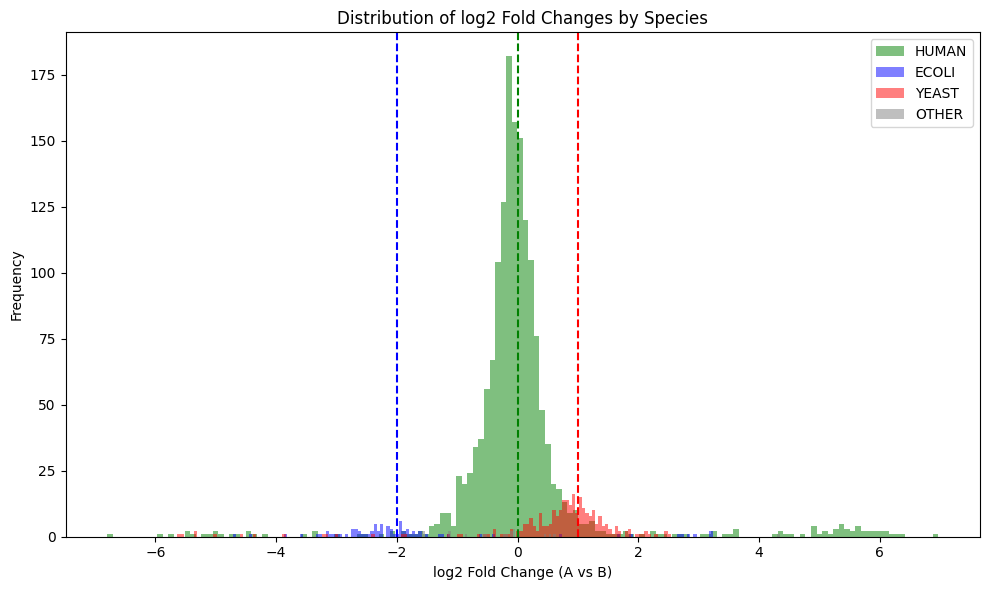

In [6]:
plot_logfc_histograms(directLFQ)